This notebook combines all well fovs for each patient into a single file.


In [1]:
import argparse
import os
import pathlib
import sys

import duckdb
import pandas as pd
from image_analysis_3D.file_utils.arg_parsing_utils import parse_args
from image_analysis_3D.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)

root_dir, in_notebook = init_notebook()

profile_base_dir = bandicoot_check(
    pathlib.Path(os.path.expanduser("~/mnt/bandicoot/NF1_organoid_data")).resolve(),
    root_dir,
)
profile_base_dir = root_dir

In [2]:
if not in_notebook:
    args = parse_args()
    patient = args["patient"]
    image_based_profiles_subparent_name = args["image_based_profiles_subparent_name"]

else:
    patient = "NF0014_T1"
    image_based_profiles_subparent_name = "image_based_profiles"

In [3]:
# set paths
profiles_path = pathlib.Path(
    f"{profile_base_dir}/data/{patient}/{image_based_profiles_subparent_name}/1.related_profiles"
).resolve(strict=True)
# output_paths
sc_merged_output_path = pathlib.Path(
    f"{profile_base_dir}/data/{patient}/{image_based_profiles_subparent_name}/2.combined_profiles/sc.parquet"
).resolve()
organoid_merged_output_path = pathlib.Path(
    f"{profile_base_dir}/data/{patient}/{image_based_profiles_subparent_name}/2.combined_profiles/organoid.parquet"
).resolve()
nucleocentric_profile_output_path = pathlib.Path(
    f"{profile_base_dir}/data/{patient}/{image_based_profiles_subparent_name}/2.combined_profiles/nucleocentric.parquet"
).resolve()
organoid_merged_output_path.parent.mkdir(parents=True, exist_ok=True)

In [4]:
# get all profiles in the directory recursively
profiles = list(profiles_path.rglob("*/*.parquet"))
# filter out profiles that are not related
profiles = [x for x in profiles if "related" in str(x)]

In [5]:
sc_profiles = [str(x) for x in profiles if "sc" in str(x.name)]
organoid_profiles = [str(x) for x in profiles if "organoid" in str(x.name)]
nucleocentric_profiles = [str(x) for x in profiles if "nucleocentric" in str(x.name)]

In [6]:
# concat all sc profiles with duckdb
with duckdb.connect() as conn:
    sc_profile = conn.execute(
        f"SELECT * FROM read_parquet({sc_profiles}, union_by_name=true)"
    ).df()
    organoid_profile = conn.execute(
        f"SELECT * FROM read_parquet({organoid_profiles}, union_by_name=true)"
    ).df()
    nucleocentric_profile = conn.execute(
        f"SELECT * FROM read_parquet({nucleocentric_profiles}, union_by_name=true)"
    ).df()
print(f"Single-cell profiles concatenated. Shape: {sc_profile.shape}")
print(f"Organoid profiles concatenated. Shape: {organoid_profile.shape}")
print(f"Nucleocentric profiles concatenated. Shape: {nucleocentric_profile.shape}")

Single-cell profiles concatenated. Shape: (13, 11889)
Organoid profiles concatenated. Shape: (1, 3962)
Nucleocentric profiles concatenated. Shape: (13, 3075)


In [7]:
sc_profile

,object_id,image_set,ParentOrganoid,Nuclei_NoChannel_AreaSizeShape_Volume,Nuclei_NoChannel_AreaSizeShape_CenterX,Nuclei_NoChannel_AreaSizeShape_CenterY,Nuclei_NoChannel_AreaSizeShape_CenterZ,Nuclei_NoChannel_AreaSizeShape_BboxVolume,Nuclei_NoChannel_AreaSizeShape_MinX,Nuclei_NoChannel_AreaSizeShape_MaxX,...,Cytoplasm_DNA_Texture_Variance-3-08-256,Cytoplasm_DNA_Texture_Variance-3-09-256,Cytoplasm_DNA_Texture_Variance-3-10-256,Cytoplasm_DNA_Texture_Variance-3-11-256,Cytoplasm_DNA_Texture_Variance-3-12-256,Nuclei_NoChannel_Neighbors_ShellAssignments,Nuclei_NoChannel_Neighbors_DistancesFromCenter,Nuclei_NoChannel_Neighbors_DistancesFromExterior,Nuclei_NoChannel_Neighbors_NormalizedDistancesFromCenter,Nuclei_NoChannel_Neighbors_ShellsUsed
0,1,C10-1,-1,4077.0,248.521707,742.226637,1.000000,5244.0,230,268,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,NaN,NaN,NaN,NaN,NaN
1,2,C10-1,1,118749.0,605.367405,796.971579,8.613917,259920.0,522,674,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,1.0,143.852716,130.890272,0.523590,3.0
2,3,C10-1,1,25340.0,578.229242,787.458761,17.628414,75710.0,522,656,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,1.0,168.433865,106.309123,0.613060,3.0
3,4,C10-1,-1,106061.0,1302.791035,1094.818746,6.935132,164268.0,1246,1363,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,NaN,NaN,NaN,NaN,NaN
4,5,C10-1,1,126753.0,569.161266,925.857045,9.330722,228105.0,516,627,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,1.0,128.051614,146.691374,0.466078,3.0
5,6,C10-1,1,5599.0,545.812109,919.354885,18.411323,8056.0,519,572,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,1.0,150.027015,124.715973,0.546063,3.0
6,7,C10-1,1,157104.0,668.010515,960.518427,13.521336,251520.0,601,732,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,0.0,59.470576,215.272412,0.216459,3.0
7,8,C10-1,1,110729.0,573.140243,999.056327,25.005256,226800.0,521,629,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,1.0,152.243739,122.499249,0.554131,3.0
8,9,C10-1,1,9325.0,585.917319,988.237641,33.457051,17920.0,547,627,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,1.0,136.005807,138.737181,0.495029,3.0
9,10,C10-1,1,122972.0,731.743551,856.795799,28.216399,208125.0,675,800,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,0.0,63.430683,211.312305,0.230873,3.0


## Remove all BF channels


In [9]:
print(f"Single-cell profiles shape: {sc_profile.shape}")
list_of_columns_to_drop = [col for col in sc_profile.columns if "BF" in col]
sc_profile = sc_profile.drop(columns=list_of_columns_to_drop)
print(f"Single-cell profiles shape after dropping BF channels: {sc_profile.shape}")

print(f"Organoid profiles shape: {organoid_profile.shape}")
list_of_columns_to_drop = [col for col in organoid_profile.columns if "BF" in col]
organoid_profile = organoid_profile.drop(columns=list_of_columns_to_drop)
print(f"Organoid profiles shape after dropping BF channels: {organoid_profile.shape}")

Single-cell profiles shape: (13, 11889)
Single-cell profiles shape after dropping BF channels: (13, 11889)
Organoid profiles shape: (1, 3962)
Organoid profiles shape after dropping BF channels: (1, 3962)


In [10]:
sc_profile.to_parquet(sc_merged_output_path, index=False)
organoid_profile.to_parquet(organoid_merged_output_path, index=False)
nucleocentric_profile.to_parquet(nucleocentric_profile_output_path, index=False)

In [11]:
sc_profile

,object_id,image_set,ParentOrganoid,Nuclei_NoChannel_AreaSizeShape_Volume,Nuclei_NoChannel_AreaSizeShape_CenterX,Nuclei_NoChannel_AreaSizeShape_CenterY,Nuclei_NoChannel_AreaSizeShape_CenterZ,Nuclei_NoChannel_AreaSizeShape_BboxVolume,Nuclei_NoChannel_AreaSizeShape_MinX,Nuclei_NoChannel_AreaSizeShape_MaxX,...,Cytoplasm_DNA_Texture_Variance-3-08-256,Cytoplasm_DNA_Texture_Variance-3-09-256,Cytoplasm_DNA_Texture_Variance-3-10-256,Cytoplasm_DNA_Texture_Variance-3-11-256,Cytoplasm_DNA_Texture_Variance-3-12-256,Nuclei_NoChannel_Neighbors_ShellAssignments,Nuclei_NoChannel_Neighbors_DistancesFromCenter,Nuclei_NoChannel_Neighbors_DistancesFromExterior,Nuclei_NoChannel_Neighbors_NormalizedDistancesFromCenter,Nuclei_NoChannel_Neighbors_ShellsUsed
0,1,C10-1,-1,4077.0,248.521707,742.226637,1.000000,5244.0,230,268,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,NaN,NaN,NaN,NaN,NaN
1,2,C10-1,1,118749.0,605.367405,796.971579,8.613917,259920.0,522,674,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,1.0,143.852716,130.890272,0.523590,3.0
2,3,C10-1,1,25340.0,578.229242,787.458761,17.628414,75710.0,522,656,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,1.0,168.433865,106.309123,0.613060,3.0
3,4,C10-1,-1,106061.0,1302.791035,1094.818746,6.935132,164268.0,1246,1363,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,NaN,NaN,NaN,NaN,NaN
4,5,C10-1,1,126753.0,569.161266,925.857045,9.330722,228105.0,516,627,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,1.0,128.051614,146.691374,0.466078,3.0
5,6,C10-1,1,5599.0,545.812109,919.354885,18.411323,8056.0,519,572,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,1.0,150.027015,124.715973,0.546063,3.0
6,7,C10-1,1,157104.0,668.010515,960.518427,13.521336,251520.0,601,732,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,0.0,59.470576,215.272412,0.216459,3.0
7,8,C10-1,1,110729.0,573.140243,999.056327,25.005256,226800.0,521,629,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,1.0,152.243739,122.499249,0.554131,3.0
8,9,C10-1,1,9325.0,585.917319,988.237641,33.457051,17920.0,547,627,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,1.0,136.005807,138.737181,0.495029,3.0
9,10,C10-1,1,122972.0,731.743551,856.795799,28.216399,208125.0,675,800,...,7.748604e-304,7.748604e-304,7.748604e-304,7.748604e-304,0.0,0.0,63.430683,211.312305,0.230873,3.0


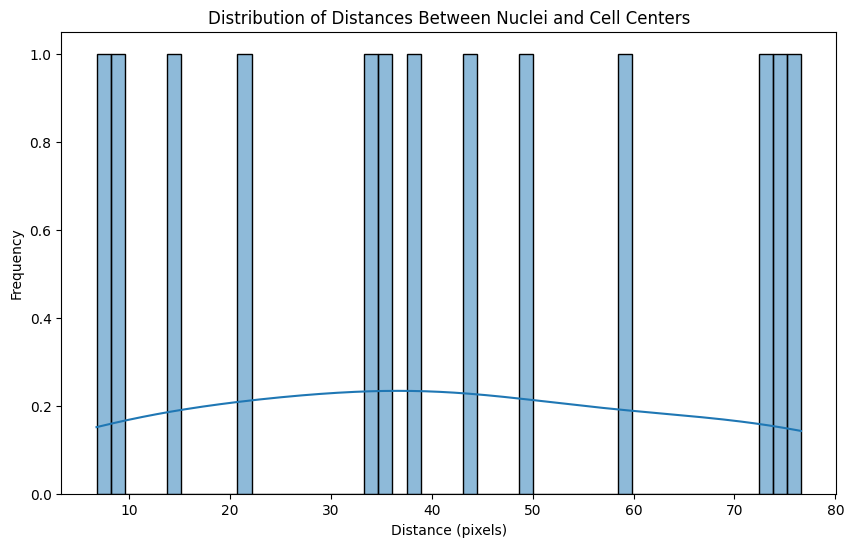

In [12]:
# check the distance of the Nulcei xy centers and the Cell xy centers for the same cell
sc_profile["Nuclei_Cell_Center_Distance"] = (
    (
        sc_profile["Nuclei_NoChannel_AreaSizeShape_CenterX"]
        - sc_profile["Cell_NoChannel_AreaSizeShape_CenterX"]
    )
    ** 2
    + (
        sc_profile["Nuclei_NoChannel_AreaSizeShape_CenterY"]
        - sc_profile["Cell_NoChannel_AreaSizeShape_CenterY"]
    )
    ** 2
) ** 0.5
sc_profile
# plot distances
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(sc_profile["Nuclei_Cell_Center_Distance"], bins=50, kde=True)
plt.title("Distribution of Distances Between Nuclei and Cell Centers")
plt.xlabel("Distance (pixels)")
plt.ylabel("Frequency")
plt.show()

In [13]:
# sanity check:
# ensure that theimage_set nuclei + cytoplasm volume is equal to the cell volume for each single cell profile
tmp_df = sc_profile.copy()
tmp_df["Nuc_plus_Cyto_Volume"] = (
    tmp_df["Nuclei_NoChannel_AreaSizeShape_Volume"]
    + tmp_df["Cytoplasm_NoChannel_AreaSizeShape_Volume"]
)
tmp_df["Volume_Discrepancy"] = (
    tmp_df["Nuc_plus_Cyto_Volume"] - tmp_df["Cell_NoChannel_AreaSizeShape_Volume"]
)
# get all the image_sets where there are volume discrepancies
tmp_df_discrepancies = tmp_df[tmp_df["Volume_Discrepancy"] != 0]
tmp_df_discrepancies["image_set"].unique()
# are the image-sets in the discrepancies also in the non discrepancy dataframe?
discrepant_image_sets = set(tmp_df_discrepancies["image_set"].unique())
non_discrepant_image_sets = set(
    tmp_df[tmp_df["Volume_Discrepancy"] == 0]["image_set"].unique()
)
intersection_image_sets = discrepant_image_sets.intersection(non_discrepant_image_sets)
print(f"Number of discrepant image sets: {len(discrepant_image_sets)}")
print(f"Number of non-discrepant image sets: {len(non_discrepant_image_sets)}")
print(
    f"Number of image sets in both discrepant and non-discrepant sets: {len(intersection_image_sets)}"
)

Number of discrepant image sets: 1
Number of non-discrepant image sets: 1
Number of image sets in both discrepant and non-discrepant sets: 1


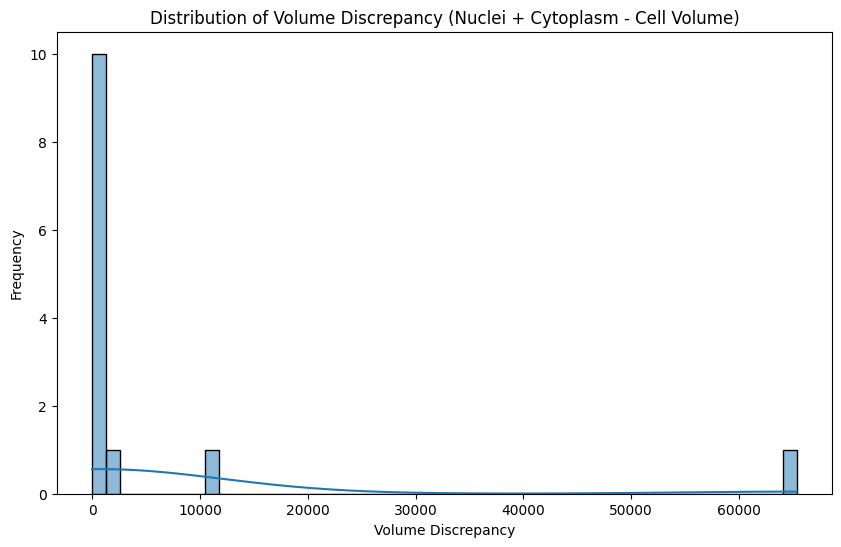

In [14]:
# plot the volume discrepancy
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(tmp_df["Volume_Discrepancy"], bins=50, kde=True)
plt.title("Distribution of Volume Discrepancy (Nuclei + Cytoplasm - Cell Volume)")
plt.xlabel("Volume Discrepancy")
plt.ylabel("Frequency")
plt.show()